# Universidad Libre - Seccional Cali<br>Facultad de Ingeniería - Diplomado en Ciencia de Datos<br>(ↄ) Daniel Andres Barona Sandoval, 2026

# 04_modelo
Plantilla para el desarrollo del proyecto del diplomado de Ciencia de Datos, aplicando buenas prácticas.

---

Este cuaderno representa la culminación del proceso, donde aplicamos técnicas de machine learning para crear modelos predictivos o descriptivos basados en los datos preparados.

**Propósito:** Desarrollar, entrenar y validar modelos de machine learning que respondan a los objetivos del proyecto.

**Tareas habituales:**
- Selección de características (feature selection)
- Ingeniería de características (feature engineering)
- División de datos en conjuntos de entrenamiento y prueba
- Selección y entrenamiento de modelos
- Optimización de hiperparámetros
- Validación cruzada
- Evaluación de métricas de rendimiento
- Documentación del proceso de modelado
- Guardado y versionado de modelos
- Análisis de importancia de características

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
import os
warnings.filterwarnings("ignore")
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
import getpass
import ipywidgets as widgets
from IPython.display import display

In [2]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.2 MB/s eta 0:00:00


In [3]:
try:
    import pmdarima as pm; HAS_PMDARIMA = True
except ImportError:
    HAS_PMDARIMA = False
    print("pmdarima no instalado; se usará búsqueda manual por AIC.")

In [4]:
!git clone https://github.com/daniel-barona/proyecto_ciencia_datos

Cloning into 'proyecto_ciencia_datos'...
remote: Enumerating objects: 426, done.
remote: Counting objects: 100% (112/112), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 426 (delta 87), reused 38 (delta 35), pack-reused 314 (from 3)
Receiving objects: 100% (426/426), 625.76 MiB | 33.69 MiB/s, done.
Resolving deltas: 100% (224/224), done.
Updating files: 100% (56/56), done.


In [5]:
folder_path = Path("/content/proyecto_ciencia_datos/data/trusted")
files = list(folder_path.glob("*.xlsx"))
print(f"Archivos encontrados: {len(files)}")
for file in files:
    print(file.name)

Archivos encontrados: 1
SIPSA_2013_2026_trusted.xlsx


# DISEÑO DEL ALGORITMO

**La idea del algoritmo es la siguiente:**

1. El usuario debe seleccinar el departamento que desee estudiar, (puede escoger los departamentos disponibles, bogota esta incluido en la lista por el datset y Colombia tambien va a estar disponible si el usuario desea hacer un estudio a nivel nacional)
2. Despues de escoger el departamento (excluyendo bogota y colombia) el usuario podra escoger entre de las ciudades de ese departamento que pertenecen y que tienen activo centros de venta mayorista para poductos alimentarios.
3. Una vez escogido se le debe mostrar los productos disponibles en la ciudad.
4. el usuario escoge el producto a investigar.
5. Alli se empieza a realizar la estadistica, la idea es hacer selecion de todas las soliitudes realizadas por el usuario y realizar un problema de serie de tiempo
- Opcion A: usar los promedios mensuales por año (solicitud del cliente)
- Opcion B: recoletar todos los datos obtenidos de la solicitud de usuario por año
6. Debe realizar el analisis, presentar las graficas, presentar promedio de mes mensual actual (hasta junio) y dar la probabilidad del precio del producto en la cuidad seleccionada.


In [6]:
trusted_dir = "/content/proyecto_ciencia_datos/data/trusted"
df = pd.read_excel(f"{trusted_dir}/SIPSA_2013_2026_trusted.xlsx")
df

,fecha,grupo,producto,mercado,departamento,codigo_departamento,municipio,codigo_municipio,precio_promedio_kg,circulacion
0,2013-01-01,carnes,alas de pollo con costillar,"barranquilla, barranquillita",atlantico,8,barranquilla,8001,3073.0,si
1,2013-01-01,carnes,alas de pollo con costillar,"bogota, d.c., frigorifico guadalupe","bogota, d.c.",11,"bogota, d.c.",11001,2560.0,si
2,2013-01-01,carnes,alas de pollo con costillar,"cartagena, bazurto",bolivar,13,cartagena de indias,13001,3429.0,si
3,2013-01-01,carnes,alas de pollo con costillar,"ibague, plaza la 21",tolima,73,ibague,73001,4307.0,si
4,2013-01-01,carnes,alas de pollo con costillar,"medellin, plaza minorista ""jose maria villa""",antioquia,5,medellin,5001,3717.0,si
...,...,...,...,...,...,...,...,...,...,...
749048,2026-06-01,frutas,manzana royal gala importada,"neiva, surabastos",huila,41,neiva,41001,8706.0,si
749049,2026-06-01,frutas,manzana royal gala importada,"monteria, mercado del sur",cordoba,23,monteria,23001,8573.0,si
749050,2026-06-01,frutas,manzana royal gala importada,"medellin, central mayorista de antioquia",antioquia,5,medellin,5001,7517.0,si
749051,2026-06-01,frutas,naranja valencia,"valledupar, mercabastos",cesar,20,valledupar,20001,2494.0,si


## Entrenar el Modelo

In [7]:
departamentos_2026 = sorted(
    df.loc[df["fecha"].dt.year == 2026, "departamento"]
      .dropna()
      .unique()
)
departamentos_2026

['antioquia',
 'arauca',
 'atlantico',
 'bogota, d.c.',
 'bolivar',
 'boyaca',
 'caldas',
 'caqueta',
 'casanare',
 'cauca',
 'cesar',
 'cordoba',
 'cundinamarca',
 'huila',
 'magdalena',
 'meta',
 'narino',
 'norte de santander',
 'quindio',
 'risaralda',
 'santander',
 'sucre',
 'tolima',
 'valle del cauca']

In [8]:
departamentos = ['colombia'] + departamentos_2026

In [35]:
dropdown_departamento = widgets.Dropdown(
    options=departamentos,
    description='Departamento:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)
display(dropdown_departamento)

Dropdown(description='Departamento:', layout=Layout(width='400px'), options=('colombia', 'antioquia', 'arauca'…

In [36]:
departamento = dropdown_departamento.value
print("Departamento seleccionado:", departamento)

Departamento seleccionado: bogota, d.c.


In [37]:
if departamento.lower() not in ['colombia', 'bogota, d.c.']:
    municipios = sorted(
        df[
            (df["departamento"] == departamento) &
            (df["fecha"].dt.year == 2026)
        ]["municipio"]
        .dropna()
        .unique()
        .tolist()
    )

    dropdown_municipio = widgets.Dropdown(
        options=municipios,
        description='Municipio:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )

    display(dropdown_municipio)

else:
    print("No es necesario seleccionar un municipio.")

No es necesario seleccionar un municipio.


In [38]:
if departamento.lower() not in ['colombia', 'bogota, d.c.']:
    municipio = dropdown_municipio.value
    print("Municipio seleccionado:", municipio)

In [39]:
if departamento.lower() == 'colombia':

    mercados = sorted(
        df[df["fecha"].dt.year == 2026]["mercado"]
        .dropna()
        .unique()
        .tolist()
    )

elif departamento.lower() == 'bogota, d.c.':

    mercados = sorted(
        df[
            (df["departamento"] == departamento) &
            (df["fecha"].dt.year == 2026)
        ]["mercado"]
        .dropna()
        .unique()
        .tolist()
    )

else:

    municipio = dropdown_municipio.value

    mercados = sorted(
        df[
            (df["municipio"] == municipio) &
            (df["fecha"].dt.year == 2026)
        ]["mercado"]
        .dropna()
        .unique()
        .tolist()
    )

dropdown_mercado = widgets.Dropdown(
    options=mercados,
    description='Mercado:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

display(dropdown_mercado)

Dropdown(description='Mercado:', layout=Layout(width='400px'), options=('bogota, d.c., carnes barrio maria paz…

In [40]:
mercado = dropdown_mercado.value
print("Mercado seleccionado:", mercado)

Mercado seleccionado: bogota, d.c., paloquemao


In [41]:
mercado = dropdown_mercado.value

productos = sorted(
    df[
        (df["mercado"] == mercado) &
        (df["fecha"].dt.year == 2026)
    ]["producto"]
    .dropna()
    .unique()
    .tolist()
)

dropdown_producto = widgets.Dropdown(
    options=productos,
    description='Producto:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

display(dropdown_producto)

Dropdown(description='Producto:', layout=Layout(width='400px'), options=('aceite girasol', 'aceite soya', 'ace…

In [42]:
producto = dropdown_producto.value
print("Producto seleccionado:", producto)

Producto seleccionado: chocolate dulce


## Inicio del Modelo - Hacer Pruebas

# Fase 1: creacion de la serie

In [43]:
def preparar_serie(df, mercado, producto):
    serie = (
        df[
            (df['mercado'] == mercado) &
            (df['producto'] == producto)
        ][['fecha', 'precio_promedio_kg']]
        .copy()
    )
    serie = serie.sort_values('fecha')
    serie.set_index('fecha', inplace=True)

    serie.rename(
        columns={'precio_promedio_kg': 'precio'},
        inplace=True,
    )
    # Si hay varios registros en la misma fecha (p.ej. municipios), promediamos
    serie = serie.groupby(serie.index).mean()
    # Frecuencia mensual + relleno de huecos
    serie = serie.asfreq('MS').interpolate('linear').ffill().bfill()
    return serie['precio']
y = preparar_serie(df, mercado, producto)
y

,precio
fecha,
2023-05-01,17733.0
2023-06-01,17850.0
2023-07-01,18383.0
2023-08-01,17910.0
2023-09-01,17792.0
2023-10-01,17987.0
2023-11-01,20333.0
2023-12-01,21096.0
2024-01-01,22175.0


## Fase 1b — Verificación del tamaño de la serie
Antes de modelar, comprueba que la serie tenga suficientes observaciones. Reglas prácticas para SARIMA con estacionalidad mensual (m=12):

- **< 24 meses**: insuficiente — no se puede estimar componente estacional.
- **24–35 meses**: mínimo aceptable — modelo poco confiable, evita SARIMA (usa ARIMA no estacional).
- **36–47 meses**: aceptable — SARIMA viable pero con incertidumbre alta.
- **48–71 meses**: bueno — recomendado (≥ 4 ciclos estacionales).
- **≥ 72 meses**: óptimo (≥ 6 ciclos).

In [44]:
def verificar_registros(y, m=12, verbose=True):
    """Evalúa si la serie tiene suficientes registros para ARIMA/SARIMA.
    Devuelve dict con: n, ciclos, nivel, recomendacion, seasonal_ok, apto.
    """
    n = int(len(y))
    n_valid = int(y.notna().sum())
    ciclos = n / m if m else 0

    if n < 24:
        nivel = 'INSUFICIENTE'
        seasonal_ok = False; apto = False
        rec = 'No hay datos suficientes. Se necesitan al menos 24 meses (2 ciclos) para modelar estacionalidad.'
    elif n < 36:
        nivel = 'MINIMO'
        seasonal_ok = False; apto = True
        rec = 'Usar ARIMA no estacional (seasonal=False) o Holt-Winters. SARIMA aún no es confiable.'
    elif n < 48:
        nivel = 'ACEPTABLE'
        seasonal_ok = True; apto = True
        rec = 'SARIMA viable pero con incertidumbre alta. Usa walk-forward y valida MASE < 1.'
    elif n < 72:
        nivel = 'BUENO'
        seasonal_ok = True; apto = True
        rec = 'Cantidad recomendada. SARIMA debería capturar bien la estacionalidad.'
    else:
        nivel = 'OPTIMO'
        seasonal_ok = True; apto = True
        rec = 'Serie larga: puedes probar SARIMA con estacionalidad completa y regresores de Fourier.'

    info = {
        'n': n, 'n_validos': n_valid, 'ciclos_estacionales': round(ciclos,2),
        'nivel': nivel, 'seasonal_ok': seasonal_ok, 'apto': apto,
        'recomendacion': rec,
    }
    if verbose:
        print(f"Registros totales : {n}")
        print(f"Registros válidos : {n_valid}")
        print(f"Ciclos (m={m})     : {ciclos:.2f}")
        print(f"Nivel             : {nivel}")
        print(f"SARIMA estacional : {'sí' if seasonal_ok else 'no'}")
        print(f"Recomendación     : {rec}")
        if not apto:
            print('\n⚠️  No continúes con el modelo hasta conseguir más datos.')
    return info

# Uso:
info = verificar_registros(y, m=12)
if not info['apto']:
    raise ValueError('Serie insuficiente para modelar.')
seasonal = info['seasonal_ok']  # pásalo a ajustar_sarima(..., seasonal=seasonal)


Registros totales : 38
Registros válidos : 38
Ciclos (m=12)     : 3.17
Nivel             : ACEPTABLE
SARIMA estacional : sí
Recomendación     : SARIMA viable pero con incertidumbre alta. Usa walk-forward y valida MASE < 1.


#Fase 3: EDA express y especifico

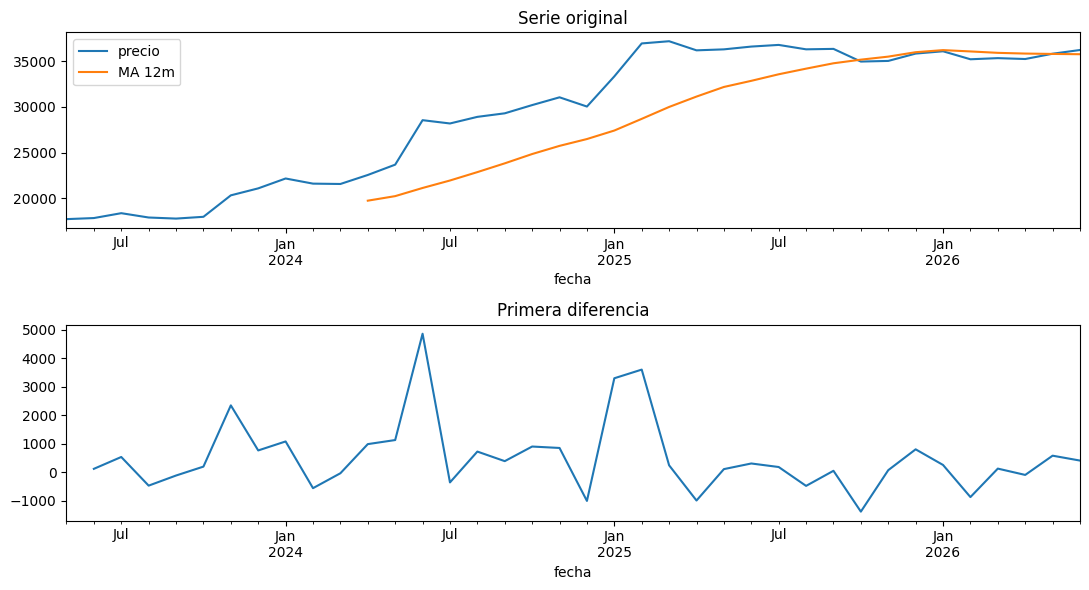

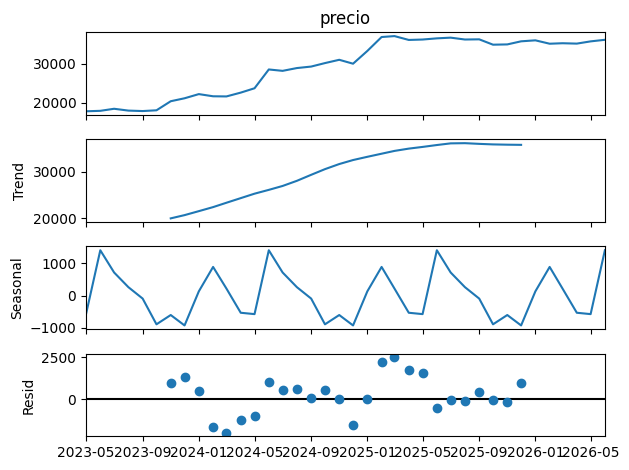

In [45]:
def eda(y):
    fig, ax = plt.subplots(2,1,figsize=(11,6))
    y.plot(ax=ax[0], title="Serie original")
    y.rolling(12).mean().plot(ax=ax[0], label="MA 12m"); ax[0].legend()
    y.diff().plot(ax=ax[1], title="Primera diferencia")
    plt.tight_layout(); plt.show()
    seasonal_decompose(y, model="additive", period=12).plot(); plt.show()
eda(y)

## Fase 3 — Estacionariedad y diferenciación

In [46]:
def test_estacionariedad(y):
    adf = adfuller(y.dropna()); kps = kpss(y.dropna(), regression="c", nlags="auto")
    print(f"ADF  p={adf[1]:.4f} (H0: no estacionaria)")
    print(f"KPSS p={kps[1]:.4f} (H0: estacionaria)")

def sugerir_diferencias(y, m=12):
    d=0; yt=y.copy()
    while adfuller(yt.dropna())[1]>0.05 and d<2:
        yt=yt.diff(); d+=1
    D=0
    if (yt.dropna().autocorr(lag=m) or 0)>0.3 and D<1:
        yt=yt.diff(m); D+=1
    print(f"Sugerencia: d={d}, D={D}"); return d,D
test_estacionariedad(y); d,D = sugerir_diferencias(y)

ADF  p=0.6183 (H0: no estacionaria)
KPSS p=0.0100 (H0: estacionaria)
Sugerencia: d=1, D=0


/tmp/ipykernel_1569/755528127.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  adf = adfuller(y.dropna()); kps = kpss(y.dropna(), regression="c", nlags="auto")


## Fase 4 — Identificación (ACF/PACF)

n efectivo tras diferenciar: 25 | lags usados: 11


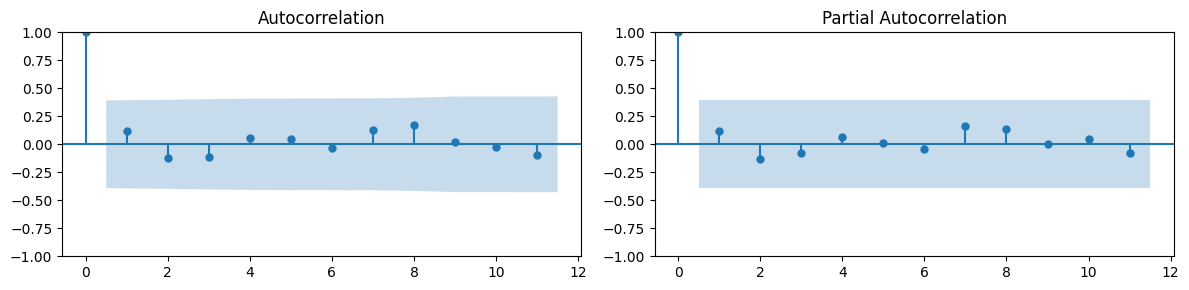

In [49]:
# Ajusta lags al tamaño de la serie: PACF exige lags < n/2
m = 12
ys = y.dropna()
# Diferenciación estacional solo si hay suficientes ciclos
y_diff = ys.diff().diff(m).dropna() if len(ys) >= 2*m + 4 else ys.diff().dropna()
n = len(y_diff)
lags = max(4, min(36, (n // 2) - 1))
print(f'n efectivo tras diferenciar: {n} | lags usados: {lags}')
fig, ax = plt.subplots(1,2, figsize=(12,3))
plot_acf(y_diff, lags=lags, ax=ax[0])
plot_pacf(y_diff, lags=lags, ax=ax[1], method='ywm')
plt.tight_layout(); plt.show()

## Fase 5 — Estimación (auto_arima / grid AIC)

In [50]:
def ajustar_sarima(y, seasonal=True, m=12, use_log=True):
    y_mod = np.log(y) if use_log else y.copy()
    if HAS_PMDARIMA:
        model = pm.auto_arima(y_mod, seasonal=seasonal, m=m,
                              d=1, D=1 if seasonal else 0,
                              stepwise=True, suppress_warnings=True,
                              error_action='ignore', trace=False)
        return model.order, model.seasonal_order, use_log
    return (1,1,1), (1,1,1,m) if seasonal else (0,0,0,0), use_log


In [54]:
order, seasonal_order, use_log = ajustar_sarima(y, seasonal=info['seasonal_ok'])
print('order=', order, 'seasonal_order=', seasonal_order, 'use_log=', use_log)

order= (0, 1, 0) seasonal_order= (1, 1, 0, 12) use_log= True


## Fase 6 — Diagnóstico de residuos

In [56]:
y_mod = np.log(y) if use_log else y
fit = SARIMAX(y_mod, order=order, seasonal_order=seasonal_order,
              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(fit.summary().tables[0])
fit.plot_diagnostics(figsize=(11,7)); plt.tight_layout(); plt.show()


                                     SARIMAX Results                                      
Dep. Variable:                             precio   No. Observations:                   38
Model:             SARIMAX(0, 1, 0)x(1, 1, 0, 12)   Log Likelihood                  20.334
Date:                            Tue, 28 Jul 2026   AIC                            -36.669
Time:                                    01:22:55   BIC                            -35.539
Sample:                                05-01-2023   HQIC                           -36.901
                                     - 06-01-2026                                         
Covariance Type:                              opg                                         


ValueError: Length of endogenous variable must be larger the the number of lags used in the model and the number of observations burned in the log-likelihood calculation.

<Figure size 1100x700 with 0 Axes>

## Fase 7 — Validación (backtest walk-forward + sMAPE / MASE)

In [29]:
def _metricas(y_true, y_pred, y_train_orig, m=12):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mape = np.mean(np.abs((y_true - y_pred)/y_true)) * 100
    smape = np.mean(2*np.abs(y_true-y_pred)/(np.abs(y_true)+np.abs(y_pred))) * 100
    # MASE: denominador = MAE del naive estacional sobre el TRAIN en escala original
    yt = np.asarray(y_train_orig)
    denom = np.mean(np.abs(yt[m:] - yt[:-m])) if len(yt) > m else np.nan
    mase = mae / denom if denom and denom>0 else np.nan
    return dict(MAE=mae, RMSE=rmse, MAPE=mape, sMAPE=smape, MASE=mase)

def backtest_wf(y, order, seasonal_order, use_log=True, h=12, m=12):
    n = len(y)
    start = n - h
    preds, reales = [], []
    for i in range(h):
        y_train = y.iloc[:start+i]
        ym = np.log(y_train) if use_log else y_train
        f = SARIMAX(ym, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        fc = f.get_forecast(steps=1)
        p = np.exp(fc.predicted_mean.iloc[0]) if use_log else fc.predicted_mean.iloc[0]
        preds.append(p); reales.append(y.iloc[start+i])
    return _metricas(reales, preds, y.iloc[:start], m=m), reales, preds

metrics, reales, preds = backtest_wf(y, order, seasonal_order, use_log=use_log, h=12)
for k,v in metrics.items(): print(f'{k:6} = {v:.3f}')


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE    = 1256.835
RMSE   = 1641.764
MAPE   = 4.222
sMAPE  = 4.245
MASE   = 0.693


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Fase 8 — Pronóstico final

In [30]:
def pronosticar(y, order, seasonal_order, use_log=True, steps=1, alpha=0.05):
    ym = np.log(y) if use_log else y
    fit = SARIMAX(ym, order=order, seasonal_order=seasonal_order,
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    fc = fit.get_forecast(steps=steps)
    mean = fc.predicted_mean
    ci = fc.conf_int(alpha=alpha)
    if use_log:
        # MISMA transformación para punto y límites -> IC coherente y contiene al punto
        mean = np.exp(mean)
        ci   = np.exp(ci)
    return mean, ci, fit

pred, ci, fit_full = pronosticar(y, order, seasonal_order, use_log=use_log, steps=6)
print(pd.concat([pred.rename('pred'), ci], axis=1))


                    pred  lower precio  upper precio
2026-07-01  30257.227985  27641.942278  33119.953589
2026-08-01  29425.956682  25894.512771  33439.012131
2026-09-01  29773.951567  25458.637350  34820.724287
2026-10-01  29303.894614  24457.056096  35111.267527
2026-11-01  29472.357650  24078.284877  36074.823015
2026-12-01  30012.183334  24050.781769  37451.221217


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Fase 9 — Persistencia y monitoreo

In [31]:
import joblib
joblib.dump({'fit':fit_full,'order':order,'seasonal_order':seasonal_order,'use_log':use_log},
            'sarima_model.pkl')
print('modelo guardado')
#Monitoreo: comparar real vs pred mes a mes; alertar si |error|>umbral.

modelo guardado


## Resumen de resultados

In [32]:
m = 12
# Naive estacional: precio del mismo mes del año pasado
naive_next = y.iloc[-m]
print(f'Naive estacional (mismo mes año pasado): {naive_next:,.2f}')

# Factor estacional histórico del mes objetivo
mes_obj = (y.index[-1] + pd.offsets.MonthBegin(1)).month
hist = y[y.index.month == mes_obj]
print(f'\nHistórico del mes {mes_obj}:')
print(hist.tail(6))
print(f'Media histórica mes {mes_obj}: {hist.mean():,.2f}')
print(f'Cambio típico vs mes previo: {((hist.values / y.reindex(hist.index - pd.offsets.MonthBegin(1)).values) - 1).mean()*100:+.1f}%')


Naive estacional (mismo mes año pasado): 27,780.00

Histórico del mes 7:
fecha
2020-07-01    15715.0
2021-07-01    19205.0
2022-07-01    25306.0
2023-07-01    26555.0
2024-07-01    25700.0
2025-07-01    27780.0
Name: precio, dtype: float64
Media histórica mes 7: 16,769.23
Cambio típico vs mes previo: +1.1%


In [33]:
def resumen(y, metrics, pred, ci, naive_next):
    ult_mes = y.index[-1].strftime('%Y-%m')
    prox = pred.index[0].strftime('%Y-%m')
    print('='*55)
    print('RESUMEN DE RESULTADOS')
    print('='*55)
    print('Métricas backtest:')
    for k,v in metrics.items(): print(f'  {k:6}= {v:.3f}')
    print('-'*55)
    print(f'Último mes observado ({ult_mes}): {y.iloc[-1]:,.2f}')
    print(f'Promedio últimos 3 meses:        {y.tail(3).mean():,.2f}')
    print(f'Naive estacional (referencia):    {naive_next:,.2f}')
    print(f'Pronóstico SARIMA ({prox}):       {pred.iloc[0]:,.2f}')
    lo, hi = ci.iloc[0,0], ci.iloc[0,1]
    print(f'  Intervalo 95%: [{lo:,.2f} ; {hi:,.2f}]')
    dentro = lo <= pred.iloc[0] <= hi
    print(f'  Punto dentro del IC: {dentro}  {"✓" if dentro else "✗ REVISAR"}')
    var = (pred.iloc[0]/y.iloc[-1]-1)*100
    print(f'  Variación vs último mes: {var:+.1f}%')
    print('='*55)

resumen(y, metrics, pred, ci, naive_next)


RESUMEN DE RESULTADOS
Métricas backtest:
  MAE   = 1256.835
  RMSE  = 1641.764
  MAPE  = 4.222
  sMAPE = 4.245
  MASE  = 0.693
-------------------------------------------------------
Último mes observado (2026-06): 30,606.00
Promedio últimos 3 meses:        30,097.00
Naive estacional (referencia):    27,780.00
Pronóstico SARIMA (2026-07):       30,257.23
  Intervalo 95%: [27,641.94 ; 33,119.95]
  Punto dentro del IC: True  ✓
  Variación vs último mes: -1.1%


**Último paso**: Guardar el Modelo para ser utilizado en el **Producto de Datos**

**Producto de Datos**:

- Aplicación Web, formulario que pide los datos y entrega la estimación/predicción/etc.
- Aplicación Móvil
- Tablero o _Dashboard_: Dash, Streamlit, Flask, PowerBI, Tableau, Qlik, Looker
- API: permite hacer las consultas para "embeberlas" en una aplicación de usuario
